# prep

In [1]:
account_path = '/content/drive/MyDrive/Personal_notebooks/Johsien_Notebook/'

In [2]:
# mount the drive
from google.colab import drive
drive.mount('/content/drive/')
from google.colab import auth
auth.authenticate_user()

# load packages - basics
!pip install pynrrd
import os
import csv
import numpy as np
import pandas as pd
import math
import time
import json
import nrrd

Drive already mounted at /content/drive/; to attempt to forcibly remount, call drive.mount("/content/drive/", force_remount=True).


In [3]:
# load packages - stats
!pip install scikit-posthocs
import scipy
from scipy import io
from scipy.fftpack import rfft, irfft, fftfreq
import scipy.stats as stats
from scipy.stats import zscore

import statsmodels.api as sm
import statsmodels.formula.api as smf
import scikit_posthocs as scikit
from statsmodels.stats.multicomp import pairwise_tukeyhsd
import statsmodels

import random
from random import randrange, shuffle
import itertools
from itertools import combinations
import sklearn
from sklearn.decomposition import PCA, FastICA
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import confusion_matrix, accuracy_score

In [4]:
# load packages - plotting and template settings
import matplotlib as mpl
from matplotlib import pyplot as plt
%matplotlib inline

from matplotlib.patches import Rectangle
import matplotlib.patches as patches
from mpl_toolkits.mplot3d import Axes3D
import matplotlib.cm as cm
import matplotlib.colors as mcolors
from matplotlib import animation
from mpl_toolkits.axes_grid1 import make_axes_locatable
import seaborn as sns
import pickle

import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)

## fcn.

In [5]:
import gspread
from google.auth import default

def read_metadata(gsheet_url,tab_name):
  """This script reads information in a tab in the Google sheet, where metadata for each experiment is stored.
  """
  # import gspread
  # from google.auth import default

  # reading in google sheet with experimental details
  creds, _ = default()
  gc = gspread.authorize(creds)

  # insert URl of gsheet, specify worksheets as different variables
  wb = gc.open_by_url(gsheet_url)
  exps = wb.worksheet(tab_name)

  #
  all_data = pd.DataFrame(exps.get_all_records())
  metadata = all_data.set_index('experiment')
  display(all_data)

  return metadata

In [6]:
from scipy.interpolate import interp1d
def resample_to_max_length(list_of_arrays):
    max_len = max(len(arr) for arr in list_of_arrays)
    resampled = []
    for arr in list_of_arrays:
        x_old = np.linspace(0, 1, len(arr))
        x_new = np.linspace(0, 1, max_len)
        f = interp1d(x_old, arr, kind='linear', fill_value='extrapolate')
        resampled.append(f(x_new))
    return np.array(resampled), max_len

## config

In [7]:
# figures output parameters
mpl.rcParams['lines.linewidth'] = 1        # default line width
mpl.rcParams['patch.linewidth'] = 0
mpl.rcParams['axes.spines.top'] = False
mpl.rcParams['axes.spines.right'] = False

# Set global Matplotlib parameters for PDF output
mpl.rcParams['pdf.fonttype'] = 42          # Use TrueType fonts (editable text)

mpl.rcParams['figure.figsize'] = (4,3)     # Default figure size in inches
mpl.rcParams['axes.titlesize'] = 16        # Title font size
mpl.rcParams['axes.labelsize'] = 14        # Axis label font size
mpl.rcParams['xtick.labelsize'] = 10       # X-axis tick label size
mpl.rcParams['ytick.labelsize'] = 10       # Y-axis tick label size
mpl.rcParams['legend.fontsize'] = 8        # Legend font size
mpl.rcParams['savefig.dpi'] = 300          # DPI for high-quality export (relevant for raster elements)
mpl.rcParams['savefig.transparent'] = True # Ensures background is transparent
sns.set(style="white",font_scale=1)     # global scaling of all texts
mpl.rcParams['xtick.bottom'] = True        # make sure ticks visible
mpl.rcParams['ytick.left'] = True

mpl.rcParams['xtick.major.width'] = 0.5    # X-axis major tick width
mpl.rcParams['ytick.major.width'] = 0.5    # Y-axis major tick width
mpl.rcParams['axes.linewidth'] = 0.5       # Axis line width

from cycler import cycler
# remove red from the default colors
mpl.rcParams['axes.prop_cycle'] = cycler('color', ['#1f77b4', '#ff7f0e', '#2ca02c', '#9467bd', '#8c564b', '#e377c2', '#7f7f7f', '#bcbd22', '#17becf'])

In [8]:
figure_path = account_path + 'Yu_escape_paper/Manuscript/Figures/figures_v7/subpanels/'
csv_path = account_path + 'Yu_escape_paper/Manuscript/Figures/figures_v7/csvs/'

# Data (dots do stuff)

In [9]:
# directories for the data and analysis
gsheet = 'https://docs.google.com/spreadsheets/d/1tpUkPiWTz_j2fthNLOIQvooPCbYnScKaoHLthi5yq18/edit?gid=106031496#gid=106031496'
tab_name = 'four_stim'

path = account_path + 'Yu_escape_paper/Imaging/Dots_do_stuff/'
data_path = path + 'Data/'
save_path = path + 'Analysis/'

metadata = read_metadata(gsheet,tab_name)
experiments = metadata.index
fcn_files = metadata.fcn_file
planeNum = metadata.planeNum
trialNum = metadata.trialNum

,experiment,fcn_file,planeNum,ROI_csv,trialNum,atlas_1,atlas_2,
0,jy-241126-f2,t2-stimR,2,2,10 9 10 10,58-77,65-84,
1,jy-241126-f4,t1-stimL,2,2,6 6 5 6,69-62,81-76,
2,jy-241126-f4,t2-stimR,2,2,5 4 5 4,76-69,83-77,
3,jy-241126-f4,t3-stimL,2,2,4 4 4 4,68-60,80-73,
4,jy-241203-f2,t1-stimL,2,2,7 7 7 8,76-58,91-74,
5,jy-241203-f2,t2-stimR,2,2,8 9 8 9,78-60,98-80,
6,jy-241203-f2,t3-stimR,1,1,10 10 10 9,88-70,,
7,jy-241203-f3,t1-stimL,2,2,9 9 10 9,75-68,88-83,
8,jy-241203-f3,t2-stimR,2,2,10 10 10 10,77-71,86-80,good brain
9,jy-241203-f3,t3-stimL,1,1,8 8 9 8,72-66,,


## stim type color scheme

In [10]:
# establish stim type num, names, and colors
resample_Hz = 10
pre, stim_dur, post = [sec*resample_Hz for sec in [5, 6, 14]] # baseline/stim on/ITI
off = 3*resample_Hz # potential response window to offset of stimulus
trial_len = pre+stim_dur+post

stim_names = ['Linear','Loom','BM','BM-escape']
stim_colorz = ['teal','purple','goldenrod','darkorange']
stim_names_3 = ['Linear','BM','BM-escape']
stim_colorz_3 = ['teal','goldenrod','darkorange']

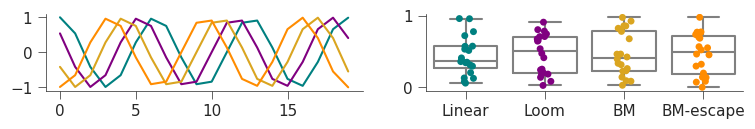

In [11]:
group_num = len(stim_names); group_names = stim_names
tmp = {n: np.random.random(20) for n in stim_names};

# validate colors settings work with both major plotting packages
plt.figure(figsize=[9,1]); plt.subplot(121);
for igs, gs in enumerate(group_names): plt.plot(np.cos(np.arange(igs,igs+20)),c=stim_colorz[igs]);
tmp = {n: np.random.random(20) for n in group_names};
plt.subplot(122); sns.boxplot(data=tmp,fill=False,color='gray'); sns.stripplot(data=tmp,palette=stim_colorz); sns.despine();
plt.show()

# S7a - mean traces to linear, BM, BM escp

across 12 fish, 40375 cells
/content/drive/MyDrive/Personal_notebooks/Johsien_Notebook/Yu_escape_paper/Manuscript/Figures/figures_v7/subpanels/S7a-mean_ind


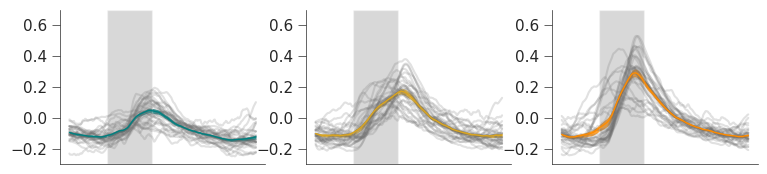

/content/drive/MyDrive/Personal_notebooks/Johsien_Notebook/Yu_escape_paper/Manuscript/Figures/figures_v7/subpanels/S7a-together


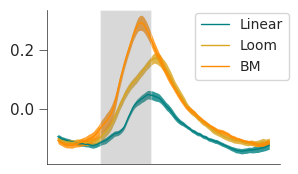

,Linear_1,Linear_2,Linear_3,Linear_4,Linear_5,Linear_6,Linear_7,Linear_8,Linear_9,Linear_10,...,BM-escp_21,BM-escp_22,BM-escp_23,BM-escp_24,BM-escp_25,BM-escp_26,BM-escp_27,BM-escp_28,BM-escp_29,BM-escp_30
0,-0.102304,-0.103986,-0.071202,-0.137586,-0.076662,-0.101426,-0.058245,-0.110938,-0.113312,-0.151988,...,-0.094884,-0.143586,-0.154273,-0.101103,-0.070377,-0.077793,-0.084234,-0.085989,-0.081871,-0.199103
1,-0.104795,-0.105817,-0.069028,-0.137859,-0.077512,-0.103056,-0.058950,-0.111872,-0.115661,-0.153638,...,-0.095392,-0.145873,-0.154931,-0.105594,-0.072441,-0.080325,-0.088085,-0.092673,-0.084121,-0.207189
2,-0.108440,-0.106623,-0.069101,-0.137070,-0.081912,-0.105940,-0.057614,-0.111818,-0.117136,-0.154546,...,-0.097188,-0.147510,-0.155715,-0.106860,-0.069077,-0.081255,-0.092926,-0.096625,-0.086053,-0.214686
3,-0.112219,-0.105974,-0.072339,-0.136213,-0.086149,-0.111004,-0.054994,-0.112236,-0.118252,-0.155014,...,-0.098674,-0.146616,-0.158091,-0.104210,-0.068111,-0.081930,-0.096176,-0.098666,-0.087154,-0.220365
4,-0.115198,-0.106006,-0.075581,-0.137934,-0.089051,-0.116992,-0.053527,-0.114869,-0.118537,-0.156636,...,-0.100356,-0.144456,-0.156739,-0.099510,-0.073042,-0.081280,-0.097686,-0.101820,-0.087559,-0.224248
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
245,-0.152917,-0.138982,-0.150468,-0.139093,-0.162805,-0.141759,-0.043515,-0.182658,-0.224884,-0.120960,...,-0.122747,-0.176838,-0.141395,-0.071992,-0.156262,-0.086405,-0.101377,-0.196025,-0.039456,-0.103386
246,-0.152077,-0.138570,-0.151318,-0.144845,-0.163470,-0.145390,-0.036553,-0.183915,-0.222964,-0.119729,...,-0.125127,-0.166881,-0.136764,-0.070699,-0.151475,-0.085643,-0.101399,-0.198759,-0.035898,-0.100163
247,-0.152491,-0.138515,-0.149002,-0.146346,-0.162104,-0.148899,-0.033638,-0.185035,-0.221637,-0.116359,...,-0.128211,-0.154278,-0.135409,-0.069655,-0.149425,-0.079828,-0.103314,-0.202959,-0.033501,-0.099361
248,-0.153986,-0.138324,-0.145107,-0.143556,-0.160063,-0.151216,-0.033768,-0.186070,-0.221219,-0.113149,...,-0.130602,-0.143267,-0.136408,-0.068750,-0.148940,-0.078133,-0.105950,-0.207076,-0.035854,-0.099524


In [ ]:
subpanel = 'S7a'

stim_names_tmp = ['Linear', 'BM', 'BM-escp']
stim_colorz_tmp = ['teal','goldenrod','darkorange']

# all social cells
across_fish_raster = [[] for i in range(len(stim_names_tmp))]
across_fish_cell_cnt = []; fish_cnt = []
for exp, ffile, plane_num, trial_num in zip(experiments[:], fcn_files[:], planeNum[:], trialNum[:]):
  # [t1, t2, t3, t4] = [int(t) for t in trial_num.split(' ')]
  load_path = data_path + exp + '/' + ffile + '/'; output_path = save_path + exp + '/' + ffile + '/'
  # print("fish #", exp, ': ', ffile)

  # get cell respnse metrics
  data = np.load(output_path+'ttest_cells_long.npz', allow_pickle=True)
  cell_id, resp_arr = data['cell_id'], data['resp_arr']
  loom_only = ((~resp_arr[0,:])*(resp_arr[1,:])*(~resp_arr[2,:])*(~resp_arr[3,:]))
  exclude = (~loom_only)

  # load PSTHs
  with open(output_path+'PSTHs.pkl', 'rb') as f:
    PSTHs = pickle.load(f) # cell_num x stim_types x x [trial_num for stim in stim_names]
  for sublist in PSTHs: sublist.pop(1) # remove response to loom to match index

  resp_raster = [[] for i in range(len(stim_names_tmp))] # use cell_arr # non-repeating
  for id in range(len(stim_names_tmp)):
    for icell in cell_id[exclude]:
      resp_raster[id].append(np.nanmean(PSTHs[icell][id],axis=0))
  resp_raster = np.array(resp_raster); #print(resp_raster.shape)

  # append to across fish stats
  for i in range(len(stim_names_tmp)):
    across_fish_raster[i].append(np.nanmean(resp_raster[i],axis=0))
  across_fish_cell_cnt.append(np.sum(exclude))
  fish_cnt.append(exp)

# across fish summary
across_fish_raster = np.array(across_fish_raster); # repsonsive type x stim type x fish x trial len
print(f"across {len(np.unique(fish_cnt))} fish, {np.sum(across_fish_cell_cnt)} cells")

# mean psth - raw
plt.figure(figsize=[9,2]);
curves = [np.nanmean(across_fish_raster[i],axis=0) for i in range(len(stim_names_tmp))]
ymin, ymax = np.min(curves), np.max(curves)
for id in range(len(stim_names_tmp)):
  plt.subplot(1,len(stim_names_tmp),id+1)
  tmp = np.array(across_fish_raster[id])
  for t in tmp: plt.plot(t,c='dimgrey',alpha=0.2)
  plt.plot(np.nanmean(tmp,axis=0),c=stim_colorz_tmp[id],lw=1)
  plt.fill_between(np.arange(trial_len), np.nanmean(tmp,axis=0)+stats.sem(tmp,axis=0,nan_policy='omit'), \
                    np.nanmean(tmp,axis=0)-stats.sem(tmp,axis=0,nan_policy='omit'),color=stim_colorz_tmp[id],alpha=0.8,lw=0)
  plt.axvspan(pre, pre+stim_dur, facecolor='gray', alpha=0.3)
  plt.ylim(-0.3,0.7);
  sns.despine(); plt.xticks([]);
print(figure_path+subpanel+"-mean_ind")
plt.savefig(figure_path+subpanel+"-mean_ind.pdf",bbox_inches='tight')
plt.show()

# mean psth - together
plt.figure(figsize=[3,2]);
curves = [np.nanmean(across_fish_raster[id],axis=0) for id in range(len(stim_names_tmp))]
ymin, ymax = np.min(curves), np.max(curves)
for id in range(len(stim_names_tmp)):
  tmp = np.array(across_fish_raster[id])
  plt.plot(np.nanmean(tmp,axis=0),c=stim_colorz_tmp[id],lw=1,label=stim_names[id])
  plt.fill_between(np.arange(trial_len), np.nanmean(tmp,axis=0)+stats.sem(tmp,axis=0,nan_policy='omit'), \
                    np.nanmean(tmp,axis=0)-stats.sem(tmp,axis=0,nan_policy='omit'),color=stim_colorz_tmp[id],alpha=0.8,lw=0)
plt.axvspan(pre, pre+stim_dur, facecolor='gray', alpha=0.3)
sns.despine(); plt.xticks([]); plt.ylim(ymin-0.1*(ymax-ymin),ymax+0.1*(ymax-ymin))
plt.legend(bbox_to_anchor=(1.05,1),markerscale=0.7,borderaxespad=0.2,fontsize=10)
print(figure_path+subpanel+"-together")
plt.savefig(figure_path+subpanel+"-together.pdf",bbox_inches='tight')
plt.show()

# save source data into csv
series_dict = {}
for istim, stim in enumerate(stim_names_tmp):
  for i, sample in enumerate(across_fish_raster[istim]):
    col_name = f"{stim}_{i+1}"
    series_dict[col_name] = sample

df = pd.DataFrame(series_dict)
display(df)
df.to_csv(csv_path+subpanel+'.csv', index=False)

# S7b - example heatmap 2x (full ver of 4h) and mean traces

fish # jy-241204-f3 :  t1-stimL
total n = 2610 responsive cells
/content/drive/MyDrive/Personal_notebooks/Johsien_Notebook/Yu_escape_paper/Manuscript/Figures/figures_v7/subpanels/S7b-1


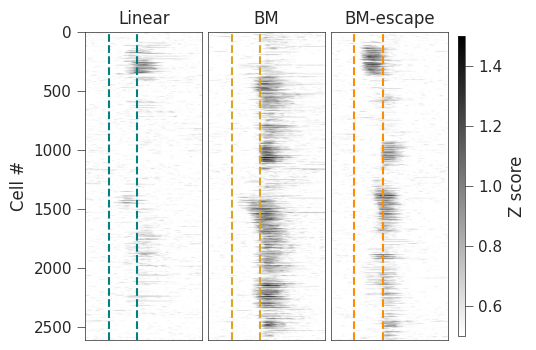

,Linear_1,Linear_2,Linear_3,Linear_4,Linear_5,Linear_6,Linear_7,Linear_8,Linear_9,Linear_10,...,BM-escape_2601,BM-escape_2602,BM-escape_2603,BM-escape_2604,BM-escape_2605,BM-escape_2606,BM-escape_2607,BM-escape_2608,BM-escape_2609,BM-escape_2610
0,-0.706961,0.052491,0.313766,0.328541,-0.695942,0.006318,0.872179,0.073911,-0.270456,0.076610,...,-0.072886,-0.109294,0.480551,0.689347,-0.027564,0.054986,-0.462273,-0.029454,0.226755,0.370815
1,-0.592054,0.031089,0.351047,0.435437,-0.531612,-0.003407,0.803748,0.099984,-0.106982,0.090853,...,-0.039110,-0.203338,0.478350,0.762487,-0.027976,0.094185,-0.513490,-0.054994,0.291951,0.372718
2,-0.463868,0.043231,0.347221,0.438798,-0.382610,0.031184,0.715560,0.184935,-0.020519,0.102735,...,-0.007723,-0.255867,0.422995,0.721279,0.006679,0.098220,-0.516526,-0.097689,0.289732,0.379271
3,-0.293542,0.052726,0.347252,0.345964,-0.284113,0.053307,0.665736,0.242318,-0.042618,0.207593,...,0.011430,-0.247024,0.381593,0.590662,0.018141,0.107660,-0.444985,-0.139120,0.249044,0.385083
4,-0.075225,0.105713,0.347283,0.313612,-0.198609,0.028723,0.578439,0.190891,-0.061512,0.384833,...,0.005694,-0.194220,0.349571,0.436559,0.030604,0.114348,-0.328292,-0.149317,0.227206,0.379128
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
245,-0.294494,0.176740,0.870526,-0.259888,-0.133054,-0.155985,-0.469039,0.020252,-0.001720,0.035435,...,0.168153,-0.227160,-0.002102,0.055650,-0.160871,-0.011999,-0.427369,-0.012170,0.203825,0.097263
246,-0.258035,0.107681,0.746552,-0.157628,-0.004867,-0.191981,-0.430454,0.045648,0.078711,0.030866,...,0.174460,-0.274395,0.117521,0.167511,-0.308054,0.040520,-0.262027,0.028567,0.051532,0.019092
247,-0.174296,0.131581,0.632296,-0.032512,0.102731,-0.236650,-0.427554,-0.016570,0.141195,0.041628,...,0.062793,-0.327888,0.180896,0.296009,-0.384734,0.073316,-0.072354,0.070239,-0.121424,-0.032822
248,-0.045755,0.222323,0.594720,0.108030,0.118763,-0.208120,-0.463129,-0.104882,0.139183,-0.033958,...,-0.019309,-0.324448,0.190211,0.326853,-0.348790,0.095891,0.047295,0.079946,-0.163763,-0.070839


fish # jy-241204-f3 :  t2-stimR
total n = 2322 responsive cells
/content/drive/MyDrive/Personal_notebooks/Johsien_Notebook/Yu_escape_paper/Manuscript/Figures/figures_v7/subpanels/S7b-2


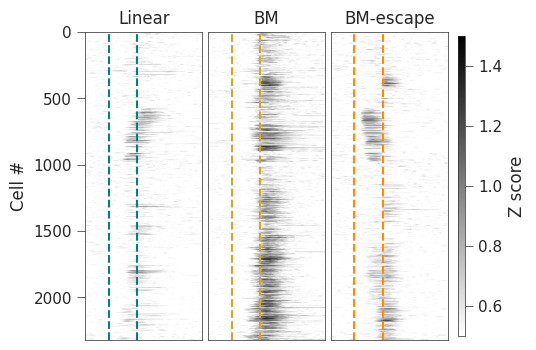

,Linear_1,Linear_2,Linear_3,Linear_4,Linear_5,Linear_6,Linear_7,Linear_8,Linear_9,Linear_10,...,BM-escape_2313,BM-escape_2314,BM-escape_2315,BM-escape_2316,BM-escape_2317,BM-escape_2318,BM-escape_2319,BM-escape_2320,BM-escape_2321,BM-escape_2322
0,-0.080866,-0.579108,0.006062,0.942525,-0.115369,-0.469199,0.147588,-0.049663,-0.292823,-0.159464,...,0.663026,-0.539430,-0.228167,-0.066206,-0.400796,0.047725,0.117974,0.393111,-0.152745,-0.067138
1,-0.001799,-0.590348,0.041752,1.123086,-0.139303,-0.467655,0.083366,-0.092017,-0.135173,-0.182095,...,0.699066,-0.519579,-0.261213,-0.080148,-0.436932,0.023171,0.194090,0.415464,-0.050263,0.009583
2,-0.006626,-0.617695,0.132870,1.124562,-0.181475,-0.361325,0.065882,-0.103550,-0.043458,-0.224972,...,0.628776,-0.449797,-0.341289,-0.081950,-0.466515,0.048741,0.192098,0.416095,-0.017788,0.103813
3,-0.059572,-0.621730,0.274287,0.965509,-0.242908,-0.184842,0.154099,-0.152896,0.005673,-0.262712,...,0.548448,-0.354602,-0.366521,-0.088053,-0.479933,0.200263,0.133745,0.373598,-0.080575,0.139650
4,-0.156580,-0.535550,0.391567,0.786337,-0.251963,-0.129403,0.143396,-0.203555,0.018192,-0.245105,...,0.543081,-0.261163,-0.332805,-0.101207,-0.490002,0.394643,0.026646,0.352433,-0.136735,0.119962
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
245,-0.312372,0.013398,0.032442,-0.352631,-0.483916,-0.254092,-0.119378,-0.261471,-0.591572,-0.351099,...,-0.083521,-0.086137,-0.292526,-0.264791,-0.374909,-0.304161,-0.366245,-0.326843,-0.323246,-0.600302
246,-0.274114,-0.139604,-0.032677,-0.371483,-0.445700,-0.191766,-0.147540,-0.221566,-0.693107,-0.362339,...,-0.076276,-0.052817,-0.272465,-0.286502,-0.390581,-0.225390,-0.311074,-0.396156,-0.319907,-0.572707
247,-0.093831,-0.251765,-0.110531,-0.384808,-0.387368,-0.194093,-0.097612,-0.196683,-0.698866,-0.384613,...,-0.067784,-0.043084,-0.259122,-0.311100,-0.419223,-0.130439,-0.286521,-0.457237,-0.311627,-0.553408
248,0.123202,-0.316610,-0.125278,-0.419004,-0.345975,-0.196780,-0.035496,-0.208887,-0.632380,-0.394380,...,-0.106533,-0.089063,-0.293083,-0.260836,-0.446889,-0.061207,-0.290751,-0.449980,-0.322459,-0.546189


In [ ]:
subpanel = 'S7b'

stim_names_tmp = ['Linear','BM','BM-escape']; stim_id_tmp = [0,2,3]
stim_colorz_tmp = ['teal','goldenrod','darkorange']

# all social cells
rep_exp_ffile = ['jy-241204-f3,t1-stimL','jy-241204-f3,t2-stimR']

across_fish_raster = [[] for i in range(len(stim_names))]
across_fish_cell_cnt = []; fish_cnt = []

for irep, rep_exp in enumerate(rep_exp_ffile):
  rep_exp, rep_ffile = rep_exp.split(',')
  for exp, ffile, plane_num, trial_num in zip(experiments[:], fcn_files[:], planeNum[:], trialNum[:]):
    if exp != rep_exp or ffile != rep_ffile: continue
    load_path = data_path + exp + '/' + ffile + '/'; output_path = save_path + exp + '/' + ffile + '/'
    print("fish #", exp, ': ', ffile)

    # get cell respnse metrics
    data = np.load(output_path+'ttest_cells_long.npz', allow_pickle=True)
    cell_id, resp_arr = data['cell_id'], data['resp_arr']
    # filters for resp type
    swim_only = ((resp_arr[2,:])*(~resp_arr[3,:])); escp_only = ((~resp_arr[2,:])*(resp_arr[3,:]))
    both = ((resp_arr[2,:])*(resp_arr[3,:])); either = ((resp_arr[2,:])+(resp_arr[3,:]))
    # exclude loom only cells
    loom_only = ((~resp_arr[0,:])*(resp_arr[1,:])*(~resp_arr[2,:])*(~resp_arr[3,:]))
    exclude = (~loom_only)

    # load PSTHs
    with open(output_path+'PSTHs.pkl', 'rb') as f:
      PSTHs = pickle.load(f) # cell_num x stim_types x x [trial_num for stim in stim_names]

    resp_raster = [[] for i in range(len(stim_names))] # use cell_arr # non-repeating
    for id in range(len(stim_names)):
      for icell in cell_id[exclude]: resp_raster[id].append(np.nanmean(PSTHs[icell][id],axis=0))
    resp_raster = np.array(resp_raster); #print(resp_raster.shape)

    # visualize
    print(f"total n = {len(cell_id[exclude])} responsive cells")
    # rastermap
    fig,_ = plt.subplots(1,len(stim_names_tmp),figsize=[5,4]) # [10,6]
    for istim in range(len(stim_names_tmp)):
      box = np.array(resp_raster[istim])
      plt.subplot(1,len(stim_names_tmp),istim+1)
      im = plt.imshow(box, cmap="gray_r", vmin=0.5, vmax=1.5, aspect="auto")
      plt.title(stim_names_tmp[istim])
      for line in [pre, pre+stim_dur]: plt.axvline(line,c=stim_colorz_tmp[istim],linestyle='--'); plt.xticks([])
      if istim>0: plt.yticks([])
      if istim==0: plt.ylabel('Cell #')
    fig.subplots_adjust(right=0.85,wspace=0.05)
    cbar_ax = fig.add_axes([0.87,0.12,0.015,0.75])  # [left, bottom, width, height]
    cbar = fig.colorbar(im, cax=cbar_ax, label='Z score'); # cbar.ax.tick_params(left=False, labelleft=False)  # Remove ticks and labels
    print(figure_path+subpanel+f"-{irep+1}")
    plt.savefig(figure_path+subpanel+f"-{irep+1}.pdf",bbox_inches='tight')
    plt.show()

    # save source data into csv
    series_dict = {}
    for istim, stim in zip(stim_id_tmp,stim_names_tmp):
      for i, sample in enumerate(resp_raster[istim]):
        col_name = f"{stim}_{i+1}"
        series_dict[col_name] = sample
    df = pd.DataFrame(series_dict)
    display(df)
    df.to_csv(csv_path+subpanel+f"-{irep+1}.csv", index=False)

# S7c-e - peaking time density map

In [ ]:
# construct arrays for social cells across fish
pre, stim_dur, post = [sec*resample_Hz for sec in [5, 6, 14]] # baseline/stim on/ITI
off = 3*resample_Hz # potential response window to offset of stimulus

giant_list = {'pk_Linear':[], 'pk_BM':[], 'pk_BM-escp':[], \
              'meanF_Linear':[], 'meanF_BM':[], 'meanF_BM-escp':[]}

for exp, ffile, plane_num, trial_num in zip(experiments[:], fcn_files[:], planeNum[:], trialNum[:]):
  [t1, t2, t3, t4] = [int(t) for t in trial_num.split(' ')]
  load_path = data_path + exp + '/' + ffile + '/'; output_path = save_path + exp + '/' + ffile + '/'
  # print("fish #", exp, ': ', ffile)
   # (1) get cell respnse metrics
  data = np.load(output_path+'ttest_cells_long.npz', allow_pickle=True)
  cell_id, resp_arr = data['cell_id'], data['resp_arr']

  # filters for resp
  swim_only = ((resp_arr[2,:])*(~resp_arr[3,:])); escp_only = ((~resp_arr[2,:])*(resp_arr[3,:]))
  both = ((resp_arr[2,:])*(resp_arr[3,:])); either = ((resp_arr[2,:])+(resp_arr[3,:]))
  # exclude loom only cells
  loom_only = ((~resp_arr[0,:])*(resp_arr[1,:])*(~resp_arr[2,:])*(~resp_arr[3,:]))
  exclude = (~loom_only)

  # load psths
  with open(output_path+'PSTHs.pkl', 'rb') as f:
    PSTHs = pickle.load(f)

  # compile responses
  big_list = {'Linear':[], 'BM':[], 'BM-escape':[]}
  for cell in cell_id[exclude]:
    # append the average psth to master list
    Linear = np.mean(np.array(PSTHs[cell][0]),axis=0); big_list['Linear'].append(Linear)
    BM = np.mean(np.array(PSTHs[cell][2]),axis=0); big_list['BM'].append(BM)
    BM_escp = np.mean(np.array(PSTHs[cell][3]),axis=0); big_list['BM-escape'].append(BM_escp)
  for key, lst in big_list.items(): big_list[key] = np.array(lst)

  # get METRICS of interest
  ## time to peak
  window = np.arange(pre,pre+stim_dur+off)
  pk_BM = np.argmax(big_list['BM'][:,window],axis=1); big_list['pk_BM'] = pk_BM/resample_Hz
  pk_BM_escp = np.argmax(big_list['BM-escape'][:,window],axis=1); big_list['pk_BM-escp'] = pk_BM_escp/resample_Hz
  pk_Linear = np.argmax(big_list['Linear'][:,window],axis=1); big_list['pk_Linear'] = pk_Linear/resample_Hz

  # append to across fish SUMMARY
  giant_list['pk_Linear'].extend(big_list['pk_Linear'])
  giant_list['pk_BM'].extend(big_list['pk_BM'])
  giant_list['pk_BM-escp'].extend(big_list['pk_BM-escp'])
  # break
for key, lst in giant_list.items(): giant_list[key] = np.array(lst)

print(f"cells repsond to either/both social stimuli N = {len(giant_list['pk_BM'])}")

cells repsond to either/both social stimuli N = 40375


In [ ]:
subpanel = 'S7cde'
# save source data into csv
series_dict = {'pk_Linear':giant_list['pk_Linear'], 'pk_BM':giant_list['pk_BM'], 'pk_BM-escp':giant_list['pk_BM-escp']}
#
df = pd.DataFrame(series_dict)
display(df)
df.to_csv(csv_path+subpanel+".csv", index=False)

,pk_Linear,pk_BM,pk_BM-escp
0,4.2,8.1,1.4
1,4.0,3.7,4.4
2,2.1,8.0,5.6
3,1.7,2.0,8.5
4,7.0,5.5,7.4
...,...,...,...
40370,8.1,2.7,1.2
40371,7.0,0.6,1.6
40372,4.6,8.2,8.5
40373,2.1,1.1,0.7


In [ ]:
# get the global kde for the three subpanels
from scipy.stats import gaussian_kde

# data of interest
x0 = np.array(giant_list['pk_Linear'],dtype=float);
x2 = np.array(giant_list['pk_BM'],dtype=float);
x3 = np.array(giant_list['pk_BM-escp'],dtype=float)

# global plotting domain
data2plot = [x0,x2,x3]
xmin, xmax = min([np.min(x) for x in data2plot]), max([np.max(x) for x in data2plot])
ymin, ymax = min([np.min(x) for x in data2plot]), max([np.max(x) for x in data2plot])

# shared grid
xi, yi = np.mgrid[xmin:xmax:100j, ymin:ymax:100j]
grid_coords = np.vstack([xi.ravel(), yi.ravel()])

# create kde for each pair of metrics
kde1 = gaussian_kde([x2, x3]); zi1 = kde1(grid_coords).reshape(xi.shape)
kde2 = gaussian_kde([x0, x3]); zi2 = kde2(grid_coords).reshape(xi.shape)
kde3 = gaussian_kde([x2, x0]); zi3 = kde3(grid_coords).reshape(xi.shape)

# make global grid of same size
global_max = max(zi1.max(), zi2.max(), zi3.max())
levels = np.linspace(0, global_max, 10)
xbins = np.linspace(xmin, xmax, 30)
ybins = np.linspace(ymin, ymax, 30)

## S7c - BM vs BM-escp

/content/drive/MyDrive/Personal_notebooks/Johsien_Notebook/Yu_escape_paper/Manuscript/Figures/figures_v7/subpanels/S7c


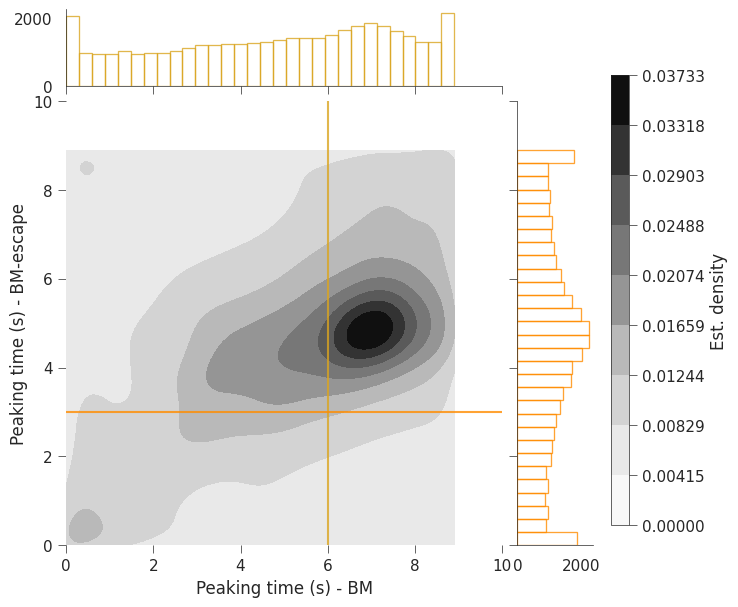

In [ ]:
subpanel = 'S7c'

# PLOT
g = sns.JointGrid(x=x2, y=x3)

# kde plot - density
cf = g.ax_joint.contourf(xi, yi, zi1, levels=levels, cmap="Greys")
cbar_ax = g.fig.add_axes([1,0.11,0.03,0.75])  # [left, bottom, width, height]
cbar = g.fig.colorbar(cf, ax=g.ax_joint, pad=0.02, aspect=30, cax=cbar_ax)
cbar.set_label("Est. density")

g.set_axis_labels(f"Peaking time (s) - {stim_names[2]}", f"Peaking time (s) - {stim_names[3]}")
sns.despine(ax=g.ax_joint, left=True, bottom=True)
g.ax_joint.set_xlim(0,10); g.ax_joint.set_ylim(0,10)
g.ax_joint.axvline(6,c=stim_colorz[2],alpha=0.8);
g.ax_joint.axhline(3,c=stim_colorz[3],alpha=0.8)

# histograms
g.plot_marginals(sns.histplot, alpha=0.6, bins=30, fill=False, kde=False)
for bar in g.ax_marg_x.patches: bar.set_edgecolor(stim_colorz[2]); bar.set_alpha(0.8);
for bar in g.ax_marg_y.patches: bar.set_edgecolor(stim_colorz[3]); bar.set_alpha(0.8)
g.ax_marg_x.tick_params(labelleft=True); g.ax_marg_y.tick_params(labelbottom=True)
g.ax_marg_x.spines['left'].set_visible(True); g.ax_marg_y.spines['bottom'].set_visible(True)

print(figure_path+subpanel)
plt.savefig(figure_path+subpanel+".pdf",bbox_inches='tight')
plt.show()

## S7d - linear vs BM-escp

/content/drive/MyDrive/Personal_notebooks/Johsien_Notebook/Yu_escape_paper/Manuscript/Figures/figures_v7/subpanels/S7d


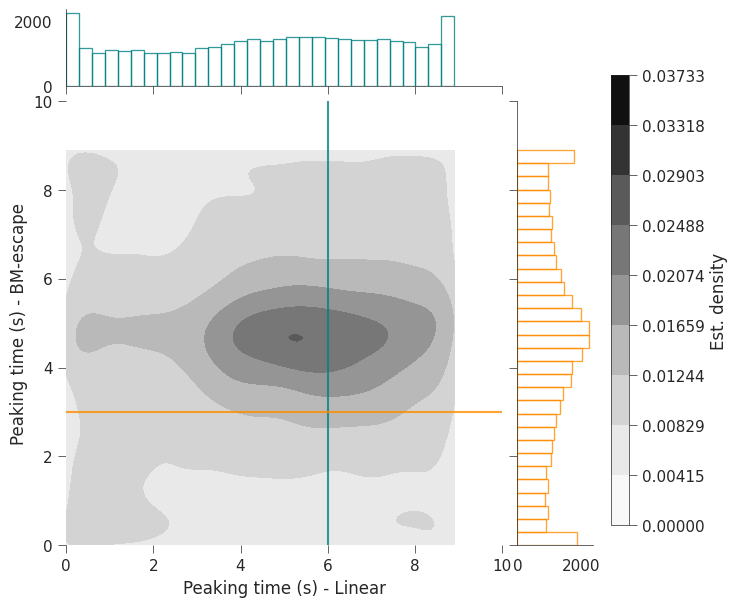

In [ ]:
subpanel = 'S7d'

# PLOT
g = sns.JointGrid(x=x0, y=x3)

# kde plot - density
cf = g.ax_joint.contourf(xi, yi, zi2, levels=levels, cmap="Greys")
cbar_ax = g.fig.add_axes([1,0.11,0.03,0.75])  # [left, bottom, width, height]
cbar = g.fig.colorbar(cf, ax=g.ax_joint, pad=0.02, aspect=30, cax=cbar_ax)
cbar.set_label("Est. density")

g.set_axis_labels(f"Peaking time (s) - {stim_names[0]}", f"Peaking time (s) - {stim_names[3]}")
sns.despine(ax=g.ax_joint, left=True, bottom=True)
g.ax_joint.set_xlim(0,10); g.ax_joint.set_ylim(0,10)
g.ax_joint.axvline(6,c=stim_colorz[0],alpha=0.8);
g.ax_joint.axhline(3,c=stim_colorz[3],alpha=0.8)

# histograms
g.plot_marginals(sns.histplot, alpha=0.6, bins=30, fill=False, kde=False)
for bar in g.ax_marg_x.patches: bar.set_edgecolor(stim_colorz[0]); bar.set_alpha(0.8);
for bar in g.ax_marg_y.patches: bar.set_edgecolor(stim_colorz[3]); bar.set_alpha(0.8)
g.ax_marg_x.tick_params(labelleft=True); g.ax_marg_y.tick_params(labelbottom=True)
g.ax_marg_x.spines['left'].set_visible(True); g.ax_marg_y.spines['bottom'].set_visible(True)

print(figure_path+subpanel)
plt.savefig(figure_path+subpanel+".pdf",bbox_inches='tight')
plt.show()

## S7e - BM vs linear

/content/drive/MyDrive/Personal_notebooks/Johsien_Notebook/Yu_escape_paper/Manuscript/Figures/figures_v7/subpanels/S7e


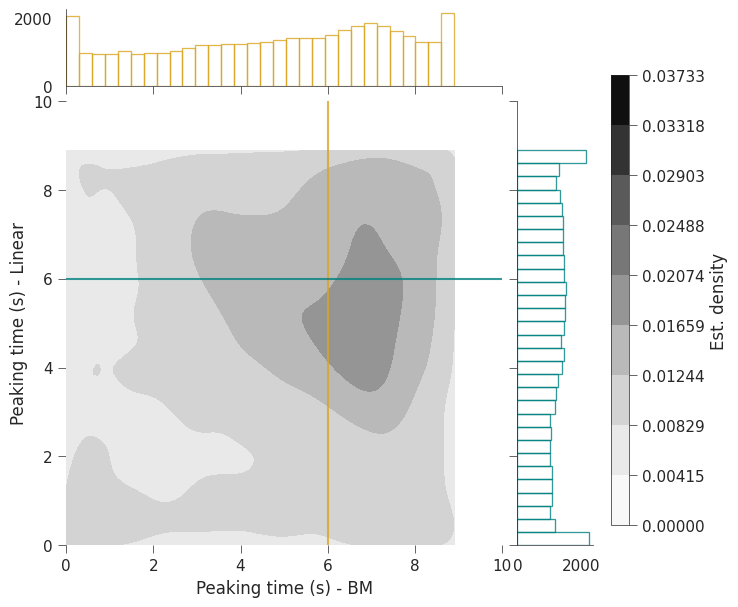

In [ ]:
subpanel = 'S7e'

# PLOT
g = sns.JointGrid(x=x2, y=x0)

# kde plot - density
cf = g.ax_joint.contourf(xi, yi, zi3, levels=levels, cmap="Greys")
cbar_ax = g.fig.add_axes([1,0.11,0.03,0.75])  # [left, bottom, width, height]
cbar = g.fig.colorbar(cf, ax=g.ax_joint, pad=0.02, aspect=30, cax=cbar_ax)
cbar.set_label("Est. density")

g.set_axis_labels(f"Peaking time (s) - {stim_names[2]}", f"Peaking time (s) - {stim_names[0]}")
sns.despine(ax=g.ax_joint, left=True, bottom=True)
g.ax_joint.set_xlim(0,10); g.ax_joint.set_ylim(0,10)
g.ax_joint.axvline(6,c=stim_colorz[2],alpha=0.8);
g.ax_joint.axhline(6,c=stim_colorz[0],alpha=0.8)

# histograms
g.plot_marginals(sns.histplot, alpha=0.6, bins=30, fill=False, kde=False)
for bar in g.ax_marg_x.patches: bar.set_edgecolor(stim_colorz[2]); bar.set_alpha(0.8);
for bar in g.ax_marg_y.patches: bar.set_edgecolor(stim_colorz[0]); bar.set_alpha(0.8)
g.ax_marg_x.tick_params(labelleft=True); g.ax_marg_y.tick_params(labelbottom=True)
g.ax_marg_x.spines['left'].set_visible(True); g.ax_marg_y.spines['bottom'].set_visible(True)

print(figure_path+subpanel)
plt.savefig(figure_path+subpanel+".pdf",bbox_inches='tight')
plt.show()

# S7f - max Z of social vs general offset cells to escp, BM, linear

In [12]:
giant_list = {'BM':[], 'BM-escape':[], 'Linear':[], 'pk_Linear':[], 'pk_BM':[], 'pk_BM-escp':[], 'fish_id':[]}

for exp, ffile, plane_num, trial_num in zip(experiments[:], fcn_files[:], planeNum[:], trialNum[:]):
  load_path = data_path + exp + '/' + ffile + '/'; output_path = save_path + exp + '/' + ffile + '/'
  # print("fish #", exp, ': ', ffile)

  # get cell respnse metrics
  data = np.load(output_path+'ttest_cells_long.npz', allow_pickle=True)
  cell_id, resp_arr = data['cell_id'], data['resp_arr']
  # filters for resp type
  swim_only = ((resp_arr[2,:])*(~resp_arr[3,:])); escp_only = ((~resp_arr[2,:])*(resp_arr[3,:]))
  both = ((resp_arr[2,:])*(resp_arr[3,:])); either = ((resp_arr[2,:])+(resp_arr[3,:]))
  # exclude loom only cells
  loom_only = ((~resp_arr[0,:])*(resp_arr[1,:])*(~resp_arr[2,:])*(~resp_arr[3,:]))
  exclude = (~loom_only)
  if np.sum(exclude) == 0: continue # skip if there's no such cells

  # load PSTHs
  with open(output_path+'PSTHs.pkl', 'rb') as f:
    PSTHs = pickle.load(f) # cell_num x stim_types x x [trial_num for stim in stim_names]
  # compile responses
  big_list = {'Linear':[], 'BM':[], 'BM-escape':[]}
  for cell in cell_id[exclude]:
    # append the average psth to master list
    Linear = np.mean(np.array(PSTHs[cell][0]),axis=0); big_list['Linear'].append(Linear)
    BM = np.mean(np.array(PSTHs[cell][2]),axis=0); big_list['BM'].append(BM)
    BM_escp = np.mean(np.array(PSTHs[cell][3]),axis=0); big_list['BM-escape'].append(BM_escp)
  for key, lst in big_list.items(): big_list[key] = np.array(lst)

  # get METRICS of interest
  ## time to peak
  window = np.arange(pre,pre+stim_dur+off)
  pk_Linear = np.argmax(big_list['Linear'][:,window],axis=1); big_list['pk_Linear'] = pk_Linear/resample_Hz
  pk_BM = np.argmax(big_list['BM'][:,window],axis=1); big_list['pk_BM'] = pk_BM/resample_Hz
  pk_BM_escp = np.argmax(big_list['BM-escape'][:,window],axis=1); big_list['pk_BM-escp'] = pk_BM_escp/resample_Hz

  # append to across fish SUMMARY
  giant_list['Linear'].extend(big_list['Linear'])
  giant_list['BM'].extend(big_list['BM'])
  giant_list['BM-escape'].extend(big_list['BM-escape'])
  giant_list['pk_Linear'].extend(big_list['pk_Linear'])
  giant_list['pk_BM'].extend(big_list['pk_BM'])
  giant_list['pk_BM-escp'].extend(big_list['pk_BM-escp'])
  giant_list['fish_id'].extend([exp] * np.sum(exclude))

  # break
for key, lst in giant_list.items():
  if key != 'fish_id': giant_list[key] = np.array(lst)

## social vs general off cells

In [ ]:
# all offset = any(swim_6-9, escape_3-6, sphere_6-9)
# social offset = (swim_6-9 AND escape_3-6) NOT spher3_6-9
# general offset = (swim_6_9 AND escape_3-6) AND sphere_6-9

In [17]:
response_window = np.arange(pre,pre+stim_dur+off)

cell_types = ['social offset','general offset']
group_values = { f"{n}_{m}": [] for n in ['BM-escape','BM','Linear'] for m in cell_types}

fish_data_for_mlm = []  # Will contain individual cell data for MLM

for cell_type in cell_types:
  summary_data = []  # Will contain fish means for each group
  print(f"\nCompare psth in {cell_type} cells:")
  if cell_type == 'social offset':
    filter1 = (giant_list['pk_BM'] >= 6)
    filter2 = (giant_list['pk_BM-escp'] >= 3)*(giant_list['pk_BM-escp'] < 6)
    filter3 = (giant_list['pk_Linear'] < 6)
    filter_mask = filter1 * filter2 * filter3
  elif cell_type == 'general offset':
    filter1 = (giant_list['pk_BM'] >= 6)
    filter2 = (giant_list['pk_BM-escp'] >= 3)*(giant_list['pk_BM-escp'] < 6)
    filter3 = (giant_list['pk_Linear'] >= 6)
    filter_mask = filter1 * filter2 * filter3

  # get mean psth of filtered cells
  stim_responses = []
  for stim in ['BM','BM-escape','Linear']:
    stim_responses.append(giant_list[stim][filter_mask])
  fish_ids_filtered = np.array(giant_list['fish_id'])[filter_mask]

  for istim, stim in enumerate(['BM','BM-escape','Linear']):
    # Calculate maximum response for each cell
    max_responses = []; fish_ids_for_mlm = []
    for cell_response, fish_id in zip(stim_responses[istim], fish_ids_filtered):
      max_response = np.max(cell_response[response_window])
      max_responses.append(max_response)
      fish_ids_for_mlm.append(fish_id)
    # Store individual cell data for MLM
    fish_data_for_mlm.extend([(cell_type, max_resp, fish_id) for max_resp, fish_id in zip(max_responses, fish_ids_for_mlm)])

    # Calculate fish means
    fish_means = []
    for fish in np.unique(fish_ids_filtered):
      fish_mask = fish_ids_filtered == fish;
      fish_mean = np.mean(np.array(max_responses)[fish_mask])
      fish_means.append(fish_mean)
    summary_data.append(fish_means)
    group_values[f"{stim}_{cell_type}"] = fish_means

  # Print basic statistics
  print(f"n = {np.sum(filter_mask)} cells")
  print("Ns (fish), means, and sems for data:")
  for id, s in enumerate(summary_data):
      print(f"{['BM','BM-escape','Linear'][id]}: N_fish={len(s)}, mean={np.mean(s):.3f}, sem={scipy.stats.sem(s):.3f}")


Compare psth in social offset cells:
n = 5237 cells
Ns (fish), means, and sems for data:
BM: N_fish=12, mean=1.068, sem=0.060
BM-escape: N_fish=12, mean=1.208, sem=0.041
Linear: N_fish=12, mean=0.579, sem=0.038

Compare psth in general offset cells:
n = 2970 cells
Ns (fish), means, and sems for data:
BM: N_fish=12, mean=0.984, sem=0.043
BM-escape: N_fish=12, mean=1.146, sem=0.038
Linear: N_fish=12, mean=0.631, sem=0.034


Each point is average of all cells in a fish
/content/drive/MyDrive/Personal_notebooks/Johsien_Notebook/Yu_escape_paper/Manuscript/Figures/figures_v7/subpanels/S7f


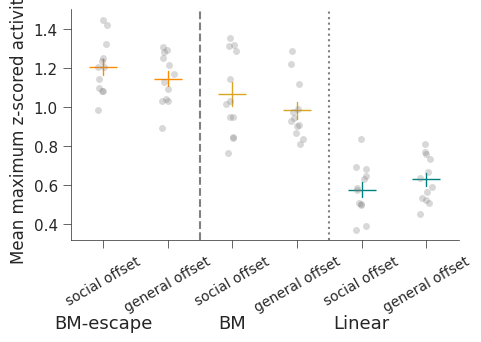

,BM_social offset,BM-escape_social offset,Linear_social offset,BM_general offset,BM-escape_general offset,Linear_general offset
0,0.949373,1.098940,0.505519,0.869522,1.030311,0.525061
1,1.354475,1.449086,0.837860,1.121286,1.308576,0.669427
2,0.847336,1.081434,0.588661,0.909699,1.042008,0.637935
3,1.318785,1.326079,0.393300,0.976960,1.169496,0.564967
4,1.143695,1.422135,0.373086,0.943755,1.285347,0.454588
5,1.031878,1.204202,0.575495,0.993598,1.216993,0.593894
6,1.286591,1.204888,0.645616,1.288340,1.253273,0.769518
7,0.845286,1.086025,0.500457,0.814064,1.034934,0.534806
8,0.763632,0.986263,0.685861,0.836447,0.895759,0.733155
9,1.312850,1.252979,0.634814,1.224006,1.294724,0.812688


In [14]:
subpanel = 'S7f'
stim_names_tmp = ['BM-escape','BM','Linear']

# PLOT
print('Each point is average of all cells in a fish')
summary_data = group_values.values()

stim_colorz_tmp = [i for i in ["darkorange","goldenrod","teal"] for t in range(2)]

plt.figure(figsize=[5,3])
sns.stripplot(data=group_values,color='gray',alpha=0.3,size=5)
sns.pointplot(data=group_values,palette=stim_colorz_tmp,\
              linestyle="none",marker="_",estimator='mean',errorbar='se',markersize=20,markeredgewidth=1,errwidth=1);
plt.xticks(rotation=90)
plt.ylabel('Mean maximum z-scored activity')
xlabels = [f"{m}" for n in stim_names_tmp for m in cell_types]
plt.xticks(range(len(xlabels)),xlabels,fontsize=10,rotation=30)
for i, stim in enumerate(['BM-escape','BM','Linear']): plt.text(2*i,plt.ylim()[0]-0.45,stim,ha='center',fontsize=13)
plt.axvline(len(cell_types)-0.5,color='gray',ls='--'); plt.axvline(len(cell_types)*2-0.5,color='gray',ls=':')
sns.despine();
print(figure_path+subpanel)
# plt.savefig(figure_path+subpanel+".pdf",bbox_inches='tight')
plt.show()

# save source data into csv
series_dict = {}
for cells in cell_types:
  for stim in ['BM','BM-escape','Linear']:
    series_dict[f"{stim}_{cells}"] = pd.Series(group_values[f"{stim}_{cells}"])
df = pd.DataFrame(series_dict)
display(df)
# df.to_csv(csv_path+subpanel+".csv", index=False)

## stats - across cell types

In [20]:
# MLM - compare response across time bins within stim type

# filter cells based on response type
cell_types = ['social offset','general offset']
response_window = np.arange(pre,pre+stim_dur+off)

group_values = {}
for n in ['BM','BM-escape','Linear']:
  for m in cell_types:
    group_values[f"{n}_{m}"] = []

# For each stimulus type, analyze maximum response by timing groups
for stim in ['BM','BM-escape','Linear']:
  print(f"\ncompare maxF to {stim} across cell types:")
  peak_metric = f'pk_{stim}' if stim != 'BM-escape' else 'pk_BM-escp'

  groups = cell_types
  summary_data = []  # Will contain fish means for each group
  fish_data_for_mlm = []  # Will contain individual cell data for MLM

  for cell_type in cell_types:
    summary_data = []  # Will contain fish means for each group
    print(f"\nCompare psth in {cell_type} cells:")
    if cell_type == 'social offset':
      filter1 = (giant_list['pk_BM'] >= 6)
      filter2 = (giant_list['pk_BM-escp'] >= 3)*(giant_list['pk_BM-escp'] < 6)
      filter3 = (giant_list['pk_Linear'] < 6)
      filter_mask = filter1 * filter2 * filter3
    elif cell_type == 'general offset':
      filter1 = (giant_list['pk_BM'] >= 6)
      filter2 = (giant_list['pk_BM-escp'] >= 3)*(giant_list['pk_BM-escp'] < 6)
      filter3 = (giant_list['pk_Linear'] >= 6)
      filter_mask = filter1 * filter2 * filter3

    # get mean psth of filtered cells
    stim_responses = giant_list[stim][filter_mask]
    fish_ids_filtered = np.array(giant_list['fish_id'])[filter_mask]

    # Calculate maximum response for each cell
    max_responses = []; fish_ids_for_mlm = []
    for cell_response, fish_id in zip(stim_responses, fish_ids_filtered):
      max_response = np.max(cell_response[response_window])
      max_responses.append(max_response)
      fish_ids_for_mlm.append(fish_id)
    # Store individual cell data for MLM
    fish_data_for_mlm.extend([(cell_type, max_resp, fish_id) for max_resp, fish_id in zip(max_responses, fish_ids_for_mlm)])

    # Calculate fish means
    fish_means = []
    for fish in np.unique(fish_ids_filtered):
      fish_mask = fish_ids_filtered == fish;
      fish_mean = np.mean(np.array(max_responses)[fish_mask])
      fish_means.append(fish_mean)
    summary_data.append(fish_means)

    group_values[f"{stim}_{cell_type}"] = fish_means

  # Print basic statistics
  print("\nNs (fish), means, and sems for data:")
  for id, s in enumerate(summary_data):
      print(f"{cell_types[id]}: N_fish={len(s)}, mean={np.mean(s):.3f}, sem={scipy.stats.sem(s):.3f}")

  # Mixed Effects Model Analysis using individual cell data
  print("\nMixed Effects Model Analysis:")
  print("Using fish ID as random effect")

  # Create DataFrame for mixed effects model using individual cell data
  df = pd.DataFrame(fish_data_for_mlm, columns=['cell_type', 'max_response', 'fish_ID'])

  # Convert group to categorical
  df['cell_type'] = df['cell_type'].astype('category')

  print(f"Total cell observations: {len(df)}")
  print(f"Groups: {df['cell_type'].unique()}")
  print(f"Cells per group: {df.groupby('cell_type').size().to_dict()}")
  print(f"Fish per group: {df.groupby('cell_type')['fish_ID'].nunique().to_dict()}")

  # Pairwise comparisons using mixed effects models
  annotation_dict = {}

  if len(groups) == 2:
      # Two groups comparison
      print(f"\nMixed effects model comparison: {groups[0]} vs {groups[1]}")

      try:
          # Fit mixed effects model
          # model = smf.mixedlm("max_response ~ cell_type", df, groups=df['fish_ID'])
          # result = model.fit()
          model = smf.mixedlm("max_response ~ cell_type", data=df, groups="fish_ID")
          result = model.fit(reml=True)
          print(result.summary())
          print("Random effect (fish_ID) variance:", result.cov_re.iloc[0,0])

          # Extract p-value for group effect
          p_values = result.pvalues
          group_p_value = p_values.iloc[1]  # Second parameter is usually the group effect

          print(f"Group effect p-value: {group_p_value:.10e}")
          annotation_dict[(groups[0], groups[1])] = group_p_value
      except Exception as e:
          print(f"Model fitting failed: {e}")
          annotation_dict[(groups[0], groups[1])] = np.nan

  elif len(groups) > 2:
      # Multiple groups - pairwise comparisons
      print(f"\nPairwise mixed effects model comparisons:")

      for g1, g2 in combinations(groups, 2):
          print(f"\nComparing {g1} vs {g2}")

          # Subset data for this comparison
          subset_df = df[df['cell_type'].isin([g1, g2])].copy()
          subset_df['cell_type'] = subset_df['cell_type'].cat.remove_unused_categories()

          try:
              # Fit mixed effects model for this pair
              # model = smf.mixedlm("max_response ~ cell_type", subset_df, groups=subset_df['fish_ID'])
              # result = model.fit(reml=False)
              model = smf.mixedlm("max_response ~ cell_type", data=df, groups="fish_ID")
              result = model.fit(reml=True)
              print(result.summary())
              print("Random effect (fish_ID) variance:", result.cov_re.iloc[0,0])

              # Extract p-value for group effect
              p_values = result.pvalues
              group_p_value = p_values.iloc[1]  # Second parameter is usually the group effect

              print(f"  Group effect p-value: {group_p_value:.10e}")
              annotation_dict[(g1, g2)] = group_p_value

          except Exception as e:
              print(f"  Model fitting failed: {e}")
              annotation_dict[(g1, g2)] = np.nan

  print(f"\nSample sizes (fish): {[len(s) for s in summary_data]}")
  print(f"Total cells analyzed: {len(df)}")


compare maxF to BM across cell types:

Compare psth in social offset cells:

Compare psth in general offset cells:

Ns (fish), means, and sems for data:
social offset: N_fish=12, mean=0.984, sem=0.043

Mixed Effects Model Analysis:
Using fish ID as random effect
Total cell observations: 8207
Groups: ['social offset', 'general offset']
Categories (2, object): ['general offset', 'social offset']
Cells per group: {'general offset': 2970, 'social offset': 5237}
Fish per group: {'general offset': 12, 'social offset': 12}

Mixed effects model comparison: social offset vs general offset
               Mixed Linear Model Regression Results
Model:                MixedLM    Dependent Variable:    max_response
No. Observations:     8207       Method:                REML        
No. Groups:           12         Scale:                 0.5661      
Min. group size:      75         Log-Likelihood:        -9334.6672  
Max. group size:      2031       Converged:             Yes         
Mean group siz

# S7g - example brain with social vs general offset cell location

fish # jy-241203-f3 :  t1-stimL
/content/drive/MyDrive/Personal_notebooks/Johsien_Notebook/Yu_escape_paper/Manuscript/Figures/figures_v7/subpanels/S7g


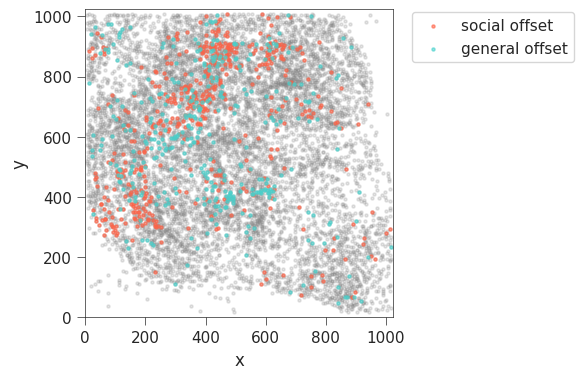

,social_x,social_y,general_x,general_y
0,898,84,840.0,49.0
1,750,100,916.0,53.0
2,585,112,862.0,66.0
3,600,127,895.0,68.0
4,657,140,871.0,67.0
...,...,...,...,...
492,580,945,NaN,NaN
493,616,970,NaN,NaN
494,383,983,NaN,NaN
495,637,998,NaN,NaN


In [ ]:
subpanel = 'S7g'

rep_exp_ffile = ['jy-241203-f3,t1-stimL'] #,'jy-241203-f3,t2-stimR']

for irep, rep_exp in enumerate(rep_exp_ffile):
  rep_exp, rep_ffile = rep_exp.split(',')
  for exp, ffile, plane_num, trial_num in zip(experiments[:], fcn_files[:], planeNum[:], trialNum[:]):
    if exp != rep_exp or ffile != rep_ffile: continue
    load_path = data_path + exp + '/' + ffile + '/'; output_path = save_path + exp + '/' + ffile + '/'
    print("fish #", exp, ': ', ffile)

    # load processed 2p info
    data = np.load(load_path+'neuron_details.npz', allow_pickle=True)
    xs, ys, zs = data['xs'], data['ys'], data['zs']

    # load psths
    with open(output_path+'PSTHs.pkl', 'rb') as f:
      PSTHs = pickle.load(f)

    # get cell respnse metrics
    data = np.load(output_path+'ttest_cells_long.npz', allow_pickle=True)
    cell_id, resp_arr = data['cell_id'], data['resp_arr']
    # filters for resp type
    swim_only = ((resp_arr[2,:])*(~resp_arr[3,:])); escp_only = ((~resp_arr[2,:])*(resp_arr[3,:]))
    both = ((resp_arr[2,:])*(resp_arr[3,:])); either = ((resp_arr[2,:])+(resp_arr[3,:]))
    # exclude loom only cells
    loom_only = ((~resp_arr[0,:])*(resp_arr[1,:])*(~resp_arr[2,:])*(~resp_arr[3,:]))
    exclude = (~loom_only)
    mask = cell_id[exclude]

    # compile responses
    big_list = {'swim':[], 'escape':[], 'sphere':[]}
    for cell in cell_id[exclude]:
      # append the average psth to master list
      swim = np.mean(np.array(PSTHs[cell][2]),axis=0); big_list['swim'].append(swim)
      escp = np.mean(np.array(PSTHs[cell][3]),axis=0); big_list['escape'].append(escp)
      sphr = np.mean(np.array(PSTHs[cell][0]),axis=0); big_list['sphere'].append(sphr)
    for key, lst in big_list.items(): big_list[key] = np.array(lst)

    # get time to peak
    window = np.arange(pre,pre+stim_dur+off)
    pk_swim = np.argmax(big_list['swim'][:,window],axis=1); big_list['pk_swim'] = pk_swim/resample_Hz
    pk_escp = np.argmax(big_list['escape'][:,window],axis=1); big_list['pk_escp'] = pk_escp/resample_Hz
    pk_sphere = np.argmax(big_list['sphere'][:,window],axis=1); big_list['pk_sphere'] = pk_sphere/resample_Hz


    fig, ax = plt.subplots(1, 1, figsize=(4,4))
    scatter = ax.scatter(xs, ys, c='grey', marker='o', s=5, alpha=0.2)

    # initiate dict to save source data into csv
    series_dict = {}

    # filter the social offset cells
    filter1 = (big_list['pk_swim'] >= 6)
    filter2 = (big_list['pk_escp'] >= 3)*(big_list['pk_escp'] < 6)
    filter3 = (big_list['pk_sphere'] < 6)
    filter_mask = filter1 * filter2 * filter3
    scatter = ax.scatter(xs[mask][filter_mask], ys[mask][filter_mask], c='tomato', marker='o', s=5, alpha=0.6, label="social offset")

    series_dict['social_x'] = pd.Series(xs[mask][filter_mask]); series_dict['social_y'] = pd.Series(ys[mask][filter_mask])

    # filter the general offset cells
    filter1 = (big_list['pk_swim'] >= 6)
    filter2 = (big_list['pk_escp'] >= 3)*(big_list['pk_escp'] < 6)
    filter3 = (big_list['pk_sphere'] >= 6)
    filter_mask = filter1 * filter2 * filter3
    scatter = ax.scatter(xs[mask][filter_mask], ys[mask][filter_mask], c='mediumturquoise', marker='o', s=5, alpha=0.6, label="general offset")

    series_dict['general_x'] = pd.Series(xs[mask][filter_mask]); series_dict['general_y'] = pd.Series(ys[mask][filter_mask])

    ax.set_xlabel('x'); ax.set_ylabel('y')
    ax.set_xlim(0,1024); ax.set_ylim(0,1024)
    plt.legend(bbox_to_anchor=(1.05,1),markerscale=1,borderaxespad=0.2)
    ax.set_aspect('equal')
    print(figure_path+subpanel)
    plt.savefig(figure_path+subpanel+f'.pdf',bbox_inches='tight')
    plt.show()

    # save source data into csv
    df = pd.DataFrame(series_dict)
    display(df)
    df.to_csv(csv_path+subpanel+f'.csv', index=False)

    # break

# S7h - social vs general offset cell per brain region

In [ ]:
# count from each session

regions = ['forebrain','midbrain','hindbrain']
total_cell_by_region = {n: 0 for n in regions};
ratio_by_region_social = {n: 0 for n in regions}
cell_by_region_social = {n: 0 for n in regions};
cell_by_region_general = {n: 0 for n in regions}

subregions = {'forebrain': ['forebrain','habenula'],'thalamus':['thalamus'],'tectum':['tectum_left','tectum_right'], 'hindbrain':['hindbrain','cerebellum']}
total_cell_by_subregion = {subreg_name: 0 for subreg_name,subreg in subregions.items()}
ratio_by_subregion_social = {subreg_name: 0 for subreg_name,subreg in subregions.items()}
cell_by_subregion_social = {subreg_name: 0 for subreg_name,subreg in subregions.items()}
cell_by_subregion_general = {subreg_name: 0 for subreg_name,subreg in subregions.items()}

for exp, ffile, plane_num in zip(experiments, fcn_files, planeNum):
  load_path = data_path + exp + '/' + ffile + '/';
  output_path = save_path + exp + '/' + ffile + '/'
  # print("fish #", exp, ': ', ffile)

  # load anatomy
  with open(load_path+'neuron_anatomy.pkl', 'rb') as f:
    cell_locations = pickle.load(f) # cell_num x stim_types x x [trial_num for stim in stim_names]

  # load PSTHs
  with open(output_path+'PSTHs.pkl', 'rb') as f:
    PSTHs = pickle.load(f) # cell_num x stim_types x x [trial_num for stim in stim_names]

  # get cell respnse metrics
  data = np.load(output_path+'ttest_cells_long.npz', allow_pickle=True)
  cell_id, resp_arr = data['cell_id'], data['resp_arr']
  # filters for resp type
  swim_only = ((resp_arr[2,:])*(~resp_arr[3,:])); escp_only = ((~resp_arr[2,:])*(resp_arr[3,:]))
  both = ((resp_arr[2,:])*(resp_arr[3,:])); either = ((resp_arr[2,:])+(resp_arr[3,:]))
  # exclude loom only cells
  loom_only = ((~resp_arr[0,:])*(resp_arr[1,:])*(~resp_arr[2,:])*(~resp_arr[3,:]))
  exclude = (~loom_only); mask = cell_id[exclude]

  # compile responses
  big_list = {'BM':[], 'BM-escape':[], 'Linear':[]}
  for cell in cell_id[exclude]:
    # append the average psth to master list
    BM = np.mean(np.array(PSTHs[cell][2]),axis=0); big_list['BM'].append(BM)
    BM_escp = np.mean(np.array(PSTHs[cell][3]),axis=0); big_list['BM-escape'].append(BM_escp)
    Linear = np.mean(np.array(PSTHs[cell][0]),axis=0); big_list['Linear'].append(Linear)
  for key, lst in big_list.items(): big_list[key] = np.array(lst)

  # get time to peak
  window = np.arange(pre,pre+stim_dur+off)
  pk_BM = np.argmax(big_list['BM'][:,window],axis=1); big_list['pk_BM'] = pk_BM/resample_Hz
  pk_BM_escp = np.argmax(big_list['BM-escape'][:,window],axis=1); big_list['pk_BM-escp'] = pk_BM_escp/resample_Hz
  pk_Linear = np.argmax(big_list['Linear'][:,window],axis=1); big_list['pk_Linear'] = pk_Linear/resample_Hz

  # get total cell cnt
  for icell in mask:
    # print(icell, cell_locations[icell])
    if cell_locations[icell] == []: continue
    for reg in regions:
      if reg in cell_locations[icell]:
        # print(f"part of {reg}")
        total_cell_by_region[reg]+=1
    for subreg_name, subregs in subregions.items():
      for subreg in subregs:
        if subreg in cell_locations[icell]:
          # print(f"also part of {subreg_name}")
          total_cell_by_subregion[subreg_name]+=1

  # filter the social offset cells
  filter1 = (big_list['pk_BM'] >= 6)
  filter2 = (big_list['pk_BM-escp'] >= 3)*(big_list['pk_BM-escp'] < 6)
  filter3 = (big_list['pk_Linear'] < 6)
  filter_mask = filter1 * filter2 * filter3

  for icell in np.arange(len(cell_locations))[mask][filter_mask]:
    # print(icell, cell_locations[icell])
    if cell_locations[icell] == []: continue
    for reg in regions:
      if reg in cell_locations[icell]:
        # print(f"part of {reg}")
        cell_by_region_social[reg]+=1
    for subreg_name, subregs in subregions.items():
      for subreg in subregs:
        if subreg in cell_locations[icell]:
          # print(f"also part of {subreg_name}")
          cell_by_subregion_social[subreg_name]+=1
  ratio_by_region_social = {n: cell_by_region_social[n]/total_cell_by_region[n]*100 for n in regions}
  ratio_by_subregion_social = {n: cell_by_subregion_social[n]/total_cell_by_subregion[n]*100 for n, _ in subregions.items()}

  # filter the general offset cells
  filter1 = (big_list['pk_BM'] >= 6)
  filter2 = (big_list['pk_BM-escp'] >= 3)*(big_list['pk_BM-escp'] < 6)
  filter3 = (big_list['pk_Linear'] >= 6)
  filter_mask = filter1 * filter2 * filter3

  for icell in np.arange(len(cell_locations))[mask][filter_mask]:
    # print(icell, cell_locations[icell])
    if cell_locations[icell] == []: continue
    for reg in regions:
      if reg in cell_locations[icell]:
        # print(f"part of {reg}")
        cell_by_region_general[reg]+=1
    for subreg_name, subregs in subregions.items():
      for subreg in subregs:
        if subreg in cell_locations[icell]:
          # print(f"also part of {subreg_name}")
          cell_by_subregion_general[subreg_name]+=1
  ratio_by_region_general = {n: cell_by_region_general[n]/total_cell_by_region[n]*100 for n in regions}
  ratio_by_subregion_general = {n: cell_by_subregion_general[n]/total_cell_by_subregion[n]*100 for n, _ in subregions.items()}
  # break
print('done')

done


/content/drive/MyDrive/Personal_notebooks/Johsien_Notebook/Yu_escape_paper/Manuscript/Figures/figures_v7/subpanels/S7h - from visually responsive cells


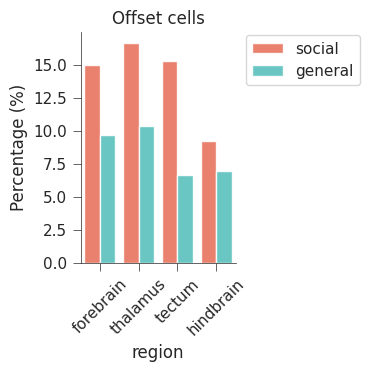

,region,count,cell_type
0,forebrain,14.966434,social
1,thalamus,16.623254,social
2,tectum,15.310166,social
3,hindbrain,9.209209,social
0,forebrain,9.688035,general
1,thalamus,10.395453,general
2,tectum,6.703475,general
3,hindbrain,6.943307,general


In [ ]:
subpanel = 'S7h'

pal_color = ['tomato','mediumturquoise']
# ratio of cells
df1 = pd.DataFrame(list(ratio_by_subregion_social.items()), columns=["region", "count"]); df1['cell_type'] = 'social'
df2 = pd.DataFrame(list(ratio_by_subregion_general.items()), columns=["region", "count"]); df2['cell_type'] = 'general'
summary_data = pd.concat([df1,df2], ignore_index=False)

# PLOT
plt.figure(figsize=[2,3])
sns.barplot(data=summary_data,x='region',y='count',hue='cell_type',palette=pal_color,alpha=0.9)
plt.ylabel('Percentage (%)'); plt.xticks(rotation=45); sns.despine(); plt.title('Offset cells')
plt.legend(bbox_to_anchor=(1.05,1),markerscale=0.7,borderaxespad=0.2)
print(figure_path+subpanel)
plt.savefig(figure_path+subpanel+".pdf",bbox_inches='tight')
plt.show()

# save source data into csv
display(summary_data)
df = pd.DataFrame(summary_data)
df.to_csv(csv_path+subpanel+'.csv')

# S7i - motion modulation of social and general offset cells

In [ ]:
# look at general offset vs social offset cells (EDF8)
giant_list_social = {f'{n}_move': [] for n in stim_names}
giant_list_social.update({f'{n}_no_move': [] for n in stim_names})
giant_list_general = {f'{n}_move': [] for n in stim_names}
giant_list_general.update({f'{n}_no_move': [] for n in stim_names})
Z_threshold = 2
trial_counts = {'move': 0, 'no_move': 0}

for exp, ffile, plane_num, trial_num in zip(experiments[:], fcn_files[:], planeNum[:], trialNum[:]):
  load_path = data_path + exp + '/' + ffile + '/'; output_path = save_path + exp + '/' + ffile + '/'
  # print("fish #", exp, ': ', ffile)

  # get cell respnse metrics
  data = np.load(output_path+'ttest_cells_long.npz', allow_pickle=True)
  cell_id, resp_arr = data['cell_id'], data['resp_arr']
  # filters for resp type
  swim_only = ((resp_arr[2,:])*(~resp_arr[3,:])); escp_only = ((~resp_arr[2,:])*(resp_arr[3,:]))
  both = ((resp_arr[2,:])*(resp_arr[3,:])); either = ((resp_arr[2,:])+(resp_arr[3,:]))
  # exclude loom only cells
  loom_only = ((~resp_arr[0,:])*(resp_arr[1,:])*(~resp_arr[2,:])*(~resp_arr[3,:]))
  exclude = (~loom_only)
  if np.sum(exclude) == 0: continue # skip if there's no such cells

  # load PSTHs
  with open(output_path+'PSTHs.pkl', 'rb') as f:
    PSTHs = pickle.load(f) # cell_num x stim_types x x [trial_num for stim in stim_names]
  # load tail PSTHs
  with open(output_path+'tail_move_psths.pkl', 'rb') as f:
    tail_Z_PSTHs = pickle.load(f) # cell_num x stim_types x x [trial_num for stim in stim_names]

  # collect tail movements
  motion_fish = {n: [] for n in stim_names} # stim x trial
  for i, stim in enumerate(stim_names):
    # tail movement
    for t in tail_Z_PSTHs[i]: m = t > Z_threshold; motion_fish[stim].append(m)

  # compile responses
  big_list = {n: [] for n in stim_names}
  for cell in cell_id:
    for i, stim in enumerate(stim_names):
      p = np.mean(np.array(PSTHs[cell][i]),axis=0); big_list[f'{stim}'].append(p)
  for key, lst in big_list.items(): big_list[key] = np.array(lst)

  # categorize single psth into whether there's movement
  big_list_social = {f'{n}_move': [] for n in stim_names}
  big_list_social.update({f'{n}_no_move': [] for n in stim_names})
  big_list_general = {f'{n}_move': [] for n in stim_names}
  big_list_general.update({f'{n}_no_move': [] for n in stim_names})

  # get peaking time
  window = np.arange(pre,pre+stim_dur+off)
  pk_Linear = np.argmax(big_list['Linear'][:,window],axis=1); big_list['pk_Linear'] = pk_Linear/resample_Hz
  pk_BM = np.argmax(big_list['BM'][:,window],axis=1); big_list['pk_BM'] = pk_BM/resample_Hz
  pk_BM_escp = np.argmax(big_list['BM-escape'][:,window],axis=1); big_list['pk_BM-escp'] = pk_BM_escp/resample_Hz

  # filter cell into social or general offset
  f1 = (big_list['pk_BM'] >= 6)
  f2 = (big_list['pk_BM-escp'] >= 3)*(big_list['pk_BM-escp'] < 6)
  f3 = (big_list['pk_Linear'] < 6)
  f4 = (big_list['pk_Linear'] >= 6)
  filter_social = f1*f2*f3
  filter_general = f1*f2*f4

  # TAIL MOTION calc
  start, end = pre, pre+stim_dur #+2*resample_Hz
  trial_cnt = {'move': 0, 'no_move': 0}
  for i, stim in enumerate(stim_names):
    for j, trial in enumerate(motion_fish[stim]):
      tmp = np.mean(trial[start:end])
      # motion_tmp[stim].append(tmp)
      if tmp>0:
        tr = np.array([PSTHs[cell][i][j] for cell in cell_id])
        big_list_social[f'{stim}_move'].append(np.mean(tr[filter_social],axis=0))
        big_list_general[f'{stim}_move'].append(np.mean(tr[filter_general],axis=0))
        trial_cnt['move'] += 1
      else:
        tr = np.array([PSTHs[cell][i][j] for cell in cell_id])
        big_list_social[f'{stim}_no_move'].append(np.mean(tr[filter_social],axis=0))
        big_list_general[f'{stim}_no_move'].append(np.mean(tr[filter_general],axis=0))
        trial_cnt['no_move'] += 1

  # append to across fish SUMMARY
  for i, stim in enumerate(stim_names):
    if len(big_list_social[f'{stim}_move']) >0:
      giant_list_social[f'{stim}_move'].append(np.mean(big_list_social[f'{stim}_move'],axis=0))
    if len(big_list_social[f'{stim}_no_move']) >0:
      giant_list_social[f'{stim}_no_move'].append(np.mean(big_list_social[f'{stim}_no_move'],axis=0))
    if len(big_list_general[f'{stim}_move']) >0:
      giant_list_general[f'{stim}_move'].append(np.mean(big_list_general[f'{stim}_move'],axis=0))
    if len(big_list_general[f'{stim}_no_move']) >0:
      giant_list_general[f'{stim}_no_move'].append(np.mean(big_list_general[f'{stim}_no_move'],axis=0))
    trial_counts['move'] += trial_cnt['move']; trial_counts['no_move'] += trial_cnt['no_move']

  # break
for key, lst in giant_list_social.items(): giant_list_social[key] = np.array(lst)
for key, lst in giant_list_general.items(): giant_list_general[key] = np.array(lst)
print(trial_counts)

{'move': 2704, 'no_move': 832}


/content/drive/MyDrive/Personal_notebooks/Johsien_Notebook/Yu_escape_paper/Manuscript/Figures/figures_v7/subpanels/S7i-social offset


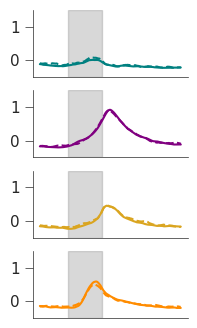

,Linear_move,Linear_no_move,Loom_move,Loom_no_move,BM_move,BM_no_move,BM-escape_move,BM-escape_no_move
0,-0.117819,-0.088108,-0.172672,-0.138651,-0.160224,-0.115833,-0.140926,-0.096276
1,-0.118210,-0.095065,-0.171481,-0.141018,-0.160375,-0.125873,-0.145089,-0.095590
2,-0.118555,-0.104525,-0.170995,-0.146160,-0.162695,-0.133999,-0.144666,-0.095103
3,-0.123520,-0.106446,-0.171978,-0.149919,-0.164919,-0.138444,-0.143672,-0.095861
4,-0.129678,-0.108673,-0.174733,-0.150312,-0.165978,-0.143581,-0.143409,-0.094361
...,...,...,...,...,...,...,...,...
245,-0.218040,-0.165192,-0.113927,-0.127521,-0.165566,-0.195161,-0.199587,-0.183630
246,-0.216766,-0.175713,-0.112555,-0.135763,-0.166584,-0.199943,-0.199150,-0.187548
247,-0.216069,-0.186883,-0.113829,-0.144823,-0.169221,-0.204815,-0.199160,-0.193766
248,-0.216595,-0.191057,-0.115823,-0.153844,-0.169846,-0.207785,-0.199217,-0.196490


/content/drive/MyDrive/Personal_notebooks/Johsien_Notebook/Yu_escape_paper/Manuscript/Figures/figures_v7/subpanels/S7i-general offset


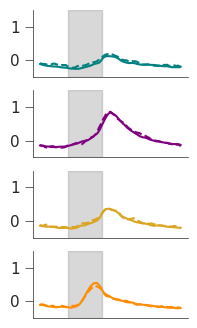

,Linear_move,Linear_no_move,Loom_move,Loom_no_move,BM_move,BM_no_move,BM-escape_move,BM-escape_no_move
0,-0.112179,-0.088108,-0.146165,-0.138651,-0.144759,-0.115833,-0.111369,-0.096276
1,-0.117802,-0.095065,-0.145577,-0.141018,-0.144273,-0.125873,-0.111119,-0.095590
2,-0.123370,-0.104525,-0.148005,-0.146160,-0.145615,-0.133999,-0.111452,-0.095103
3,-0.127388,-0.106446,-0.151988,-0.149919,-0.150081,-0.138444,-0.111630,-0.095861
4,-0.130962,-0.108673,-0.155987,-0.150312,-0.154329,-0.143581,-0.110084,-0.094361
...,...,...,...,...,...,...,...,...
245,-0.209440,-0.165192,-0.108711,-0.127521,-0.203253,-0.195161,-0.209097,-0.183630
246,-0.208890,-0.175713,-0.112217,-0.135763,-0.204333,-0.199943,-0.208146,-0.187548
247,-0.206028,-0.186883,-0.118321,-0.144823,-0.204792,-0.204815,-0.204793,-0.193766
248,-0.198330,-0.191057,-0.124629,-0.153844,-0.206055,-0.207785,-0.203170,-0.196490


In [ ]:
subpanel = 'S7i'
# VISUALIZAE
plt.figure(figsize=[2,4])
# plt.subplot(121)
for i, stim in enumerate(stim_names):
  plt.subplot(4,1,i+1)
  m = np.mean(giant_list_social[f'{stim}_move'],axis=0)
  plt.plot(m, color=stim_colorz[i], label=f'{stim}_move')
  nm = np.mean(giant_list_social[f'{stim}_no_move'],axis=0)
  plt.plot(nm, color=stim_colorz[i], ls='--',label=f'{stim} w/o motion')
  plt.xticks([]); #plt.xlim(pre-2*resample_Hz,pre+stim_dur+4*resample_Hz)
  sns.despine(); plt.axvspan(pre, pre+stim_dur, color='gray', alpha=0.3)
  plt.ylim(-0.5,1.5)
# plt.title('Social offset')
print(figure_path+subpanel+'-social offset')
plt.savefig(figure_path+subpanel+'-social offset.pdf',bbox_inches='tight')
plt.show()

# save source data into csv
series_dict = {}

for i, stim in enumerate(stim_names):
  m = np.mean(giant_list_social[f'{stim}_move'],axis=0)
  nm = np.mean(giant_list_general[f'{stim}_no_move'],axis=0)
  series_dict[f'{stim}_move'] = pd.Series(m)
  series_dict[f'{stim}_no_move'] = pd.Series(nm)
df = pd.DataFrame(series_dict)
display(df)
df.to_csv(csv_path+subpanel+'-social offset.csv', index=False)

# VISUALIZAE
plt.figure(figsize=[2,4])
# plt.subplot(121)
for i, stim in enumerate(stim_names):
  plt.subplot(4,1,i+1)
  m = np.mean(giant_list_general[f'{stim}_move'],axis=0)
  plt.plot(m, color=stim_colorz[i], label=f'{stim}_move')
  nm = np.mean(giant_list_general[f'{stim}_no_move'],axis=0)
  plt.plot(nm, color=stim_colorz[i], ls='--',label=f'{stim} w/o motion')
  plt.xticks([]); #plt.xlim(pre-2*resample_Hz,pre+stim_dur+4*resample_Hz)
  sns.despine(); plt.axvspan(pre, pre+stim_dur, color='gray', alpha=0.3)
  plt.ylim(-0.5,1.5)

print(figure_path+subpanel+'-general offset')
plt.savefig(figure_path+subpanel+'-general offset.pdf',bbox_inches='tight')
plt.show()

# save source data into csv
series_dict = {}

for i, stim in enumerate(stim_names):
  m = np.mean(giant_list_general[f'{stim}_move'],axis=0)
  nm = np.mean(giant_list_general[f'{stim}_no_move'],axis=0)
  series_dict[f'{stim}_move'] = pd.Series(m)
  series_dict[f'{stim}_no_move'] = pd.Series(nm)
df = pd.DataFrame(series_dict)
display(df)
df.to_csv(csv_path+subpanel+'-general offset.csv', index=False)